# Количественное сравнение методов unfold_

Адаптированный порт ноутбука `29-unfold_methods_comparison.ipynb` из ветки
`сравнение-методов-unfold_-1e916`, переписанный под текущий публичный API
`Detector.unfold_*` и функцию `benchmark_unfold_methods` из
`bssunfold.utils.comparison`.

## Цели
1. Перебрать параметры каждого метода (полный набор ~17 методов).
2. Составить таблицу метрик восстановления спектра.
3. Выдать отчёт по методам и ранжирование (какой метод лучше?).
4. Построить графики спектров и метрик.

> Примечание: полный прогон всех методов по всем спектрам может занять
> несколько минут. Для быстрого старта уменьшите `TEST_SPECTRA`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
try:
    import seaborn as sns
    sns.set_style('whitegrid')
except ImportError:
    sns = None

from bssunfold import Detector, RF_LANL
from bssunfold.utils.comparison import (
    benchmark_unfold_methods,
    DEFAULT_UNFOLD_BENCHMARK_METHODS,
    DEFAULT_UNFOLD_BENCHMARK_METRICS,
)

print("bssunfold benchmark harness loaded")

bssunfold benchmark harness loaded


## Загрузка детектора и данных

In [2]:
det = Detector(RF_LANL)
print(f"Количество энергетических бинов: {det.n_energy_bins}")
print(f"Количество сфер детектора: {len(det.detector_names)}")
print(f"Сферы: {det.detector_names}")

Количество энергетических бинов: 60
Количество сфер детектора: 11
Сферы: ['3in', '4in', '5in', '6in', '8in', '9in', '12in', '18in', '9inPb', '12inPb', '18inPb']


In [3]:
spectra_df = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f"Размер базы спектров: {spectra_df.shape}")
spectrum_names = [col for col in spectra_df.columns if col != 'E_MeV']
print(f"Названия спектров: {len(spectrum_names)}")

Размер базы спектров: (61, 21)
Названия спектров: 20


## Подготовка эталонных спектров

Спектры из базы IAEA могут быть заданы на сетке, отличной от сетки детектора.
Ресемплируем каждый эталон на `det.E_MeV`, чтобы `det.compare` корректно
считал метрики (требуется совпадение числа бинов).

In [4]:
def get_reference_spectrum(df, name):
    src_e = df['E_MeV'].values
    src_phi = df[name].values
    # Ресемплинг на сетку детектора
    phi = np.interp(det.E_MeV, src_e, src_phi)
    return {'E_MeV': det.E_MeV, 'Phi': phi}

## Конфигурация методов

Используем `DEFAULT_UNFOLD_BENCHMARK_METHODS` — реестр всех ~17 методов с
актуальными именами параметров текущего API (`max_iterations`, `k`,
`epsilon`, `sigma_factor`, `solver`). При желании можно переопределить
сетки параметров или оставить подмножество методов.

In [5]:
METHODS = DEFAULT_UNFOLD_BENCHMARK_METHODS
METRICS = DEFAULT_UNFOLD_BENCHMARK_METRICS
print(f"Методов в конфигурации: {len(METHODS)}")
print("Метрики:", METRICS)

Методов в конфигурации: 17
Метрики: ['r2_score', 'pearson_r', 'root_mean_squared_error', 'mape', 'wasserstein_dist', 'kl_divergence', 'cosine_similarity']


In [6]:
# Для быстрого старта можно ограничить число спектров, например первыми 3.
# Для полного бенчмарка (как в ветке) используйте весь список spectrum_names.
TEST_SPECTRA = spectrum_names[:3]
print(f"Тестируем {len(TEST_SPECTRA)} спектров на {len(METHODS)} методах")

Тестируем 3 спектров на 17 методах


## Прогон бенчмарка

`benchmark_unfold_methods` для каждого спектра вычисляет показания детектора,
прогоняет все методы по их сеткам параметров, считает метрики через
`det.compare` и возвращает таблицу результатов, сводную таблицу, ранжирование
и текстовый отчёт.

In [7]:
refs = {name: get_reference_spectrum(spectra_df, name) for name in TEST_SPECTRA}

result = benchmark_unfold_methods(
    det,
    refs,
    methods=METHODS,
    metrics=METRICS,
    rank_by='r2_score',
    progress=True,
)

print(f"\nВсего экспериментов: {len(result.results)}")

  ISO_ref_Cf252/mlem: ok (0.64s)
  ISO_ref_Cf252/mlem: ok (0.00s)
  ISO_ref_Cf252/mlem: ok (0.00s)
  ISO_ref_Cf252/maxed: ok (0.16s)
  ISO_ref_Cf252/maxed: ok (0.17s)
  ISO_ref_Cf252/maxed: ok (0.17s)
  ISO_ref_Cf252/tsvd: ok (0.00s)
  ISO_ref_Cf252/tsvd: ok (0.00s)
  ISO_ref_Cf252/tsvd: ok (0.00s)
  ISO_ref_Cf252/bayes: ok (0.00s)
  ISO_ref_Cf252/bayes: ok (0.00s)
  ISO_ref_Cf252/cvxpy: ok (0.15s)
  ISO_ref_Cf252/cvxpy: ok (0.01s)
  ISO_ref_Cf252/landweber: ok (0.00s)
  ISO_ref_Cf252/landweber: ok (0.00s)
  ISO_ref_Cf252/sart: ok (0.00s)
  ISO_ref_Cf252/sart: ok (0.00s)
  ISO_ref_Cf252/kaczmarz: ok (0.00s)
  ISO_ref_Cf252/kaczmarz: ok (0.00s)
  ISO_ref_Cf252/cgls: ok (0.00s)
  ISO_ref_Cf252/cgls: ok (0.00s)
  ISO_ref_Cf252/lanczos: ok (0.01s)
  ISO_ref_Cf252/lanczos: ok (0.08s)
  ISO_ref_Cf252/tikhonov_tv: ok (0.01s)
  ISO_ref_Cf252/tikhonov_tv: ok (0.01s)
  ISO_ref_Cf252/gravel: ok (0.00s)
  ISO_ref_Cf252/gravel: ok (0.00s)
  ISO_ref_Cf252/doroshenko: ok (0.00s)
  ISO_ref_Cf252/doros

## Сводная таблица метрик (среднее / СКО по методам)

In [8]:
summary_table = result.summary
print("Сводная таблица метрик:")
print(summary_table.to_string())

Сводная таблица метрик:
         method  r2_score_mean  pearson_r_mean  root_mean_squared_error_mean    mape_mean  wasserstein_dist_mean  kl_divergence_mean  cosine_similarity_mean  r2_score_std  pearson_r_std  root_mean_squared_error_std     mape_std  wasserstein_dist_std  kl_divergence_std  cosine_similarity_std
0         bayes      -1.588797        0.490333                      0.103402   157.502186               0.017951            0.416774                0.648856      1.937767       0.361791                     0.074373   134.132956              0.006640           0.166732               0.226988
1         bunki       0.725619        0.869344                      0.042615   432.155896               0.018454            0.294088                0.906371      0.120086       0.071220                     0.023245   558.973877              0.008437           0.151772               0.047756
2          cgls       0.927971        0.963635                      0.017220   190.841828           

## Рейтинг методов (по R²)

In [9]:
ranking = result.ranking
print("Рейтинг по R² (убывание):")
print(ranking[['method', 'r2_score_mean'] + [c for c in ranking.columns if c.endswith('_mean') and c != 'r2_score_mean']].to_string(index=False))

Рейтинг по R² (убывание):
     method  r2_score_mean  pearson_r_mean  root_mean_squared_error_mean   mape_mean  wasserstein_dist_mean  kl_divergence_mean  cosine_similarity_mean
      cvxpy       0.986582        0.993253                      0.005147   25.021103               0.001854            0.072767                0.996691
       cgls       0.927971        0.963635                      0.017220  190.841828               0.007073            0.147090                0.979051
       tsvd       0.914041        0.955958                      0.017320  190.406209               0.007226            0.152816                0.976122
       osem       0.729596        0.873299                      0.039719  539.678477               0.018909            0.317628                0.906054
     sandii       0.726256        0.873841                      0.040426  437.898146               0.018821            0.310565                0.912918
      bunki       0.725619        0.869344                    

## Графики метрик по методам

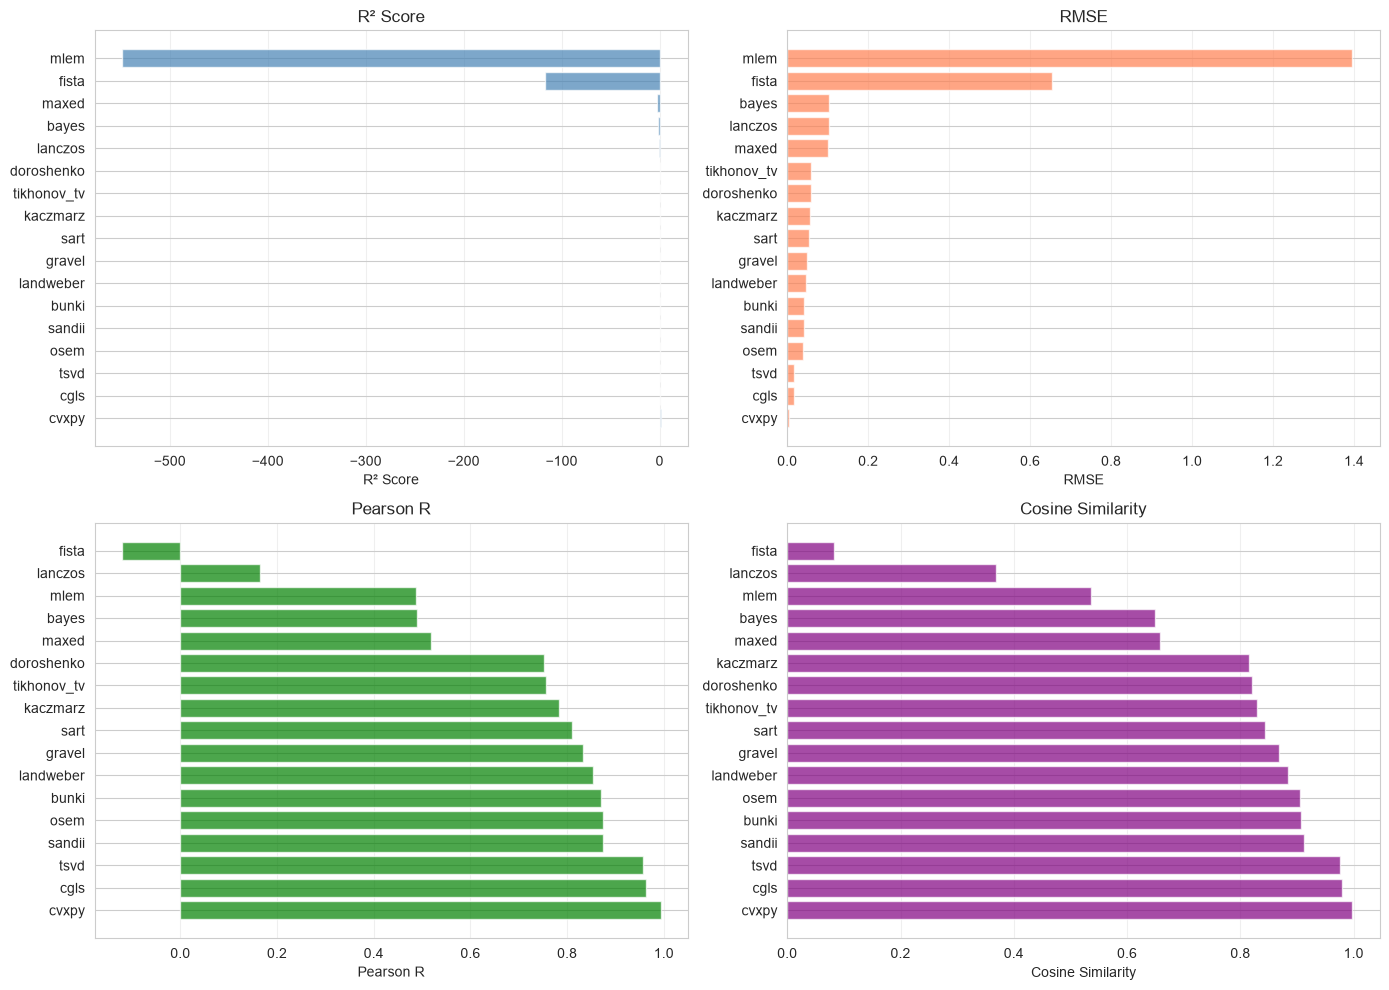

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_plot = [
    ('r2_score_mean', 'R² Score', 'steelblue'),
    ('root_mean_squared_error_mean', 'RMSE', 'coral'),
    ('pearson_r_mean', 'Pearson R', 'green'),
    ('cosine_similarity_mean', 'Cosine Similarity', 'purple'),
]
for ax, (col, title, color) in zip(axes.flat, metrics_plot):
    if col not in summary_table.columns:
        continue
    data = summary_table.sort_values(col, ascending=('RMSE' in title or 'Error' in title))
    ax.barh(data['method'], data[col], color=color, alpha=0.7)
    ax.set_xlabel(title)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Точность vs Время

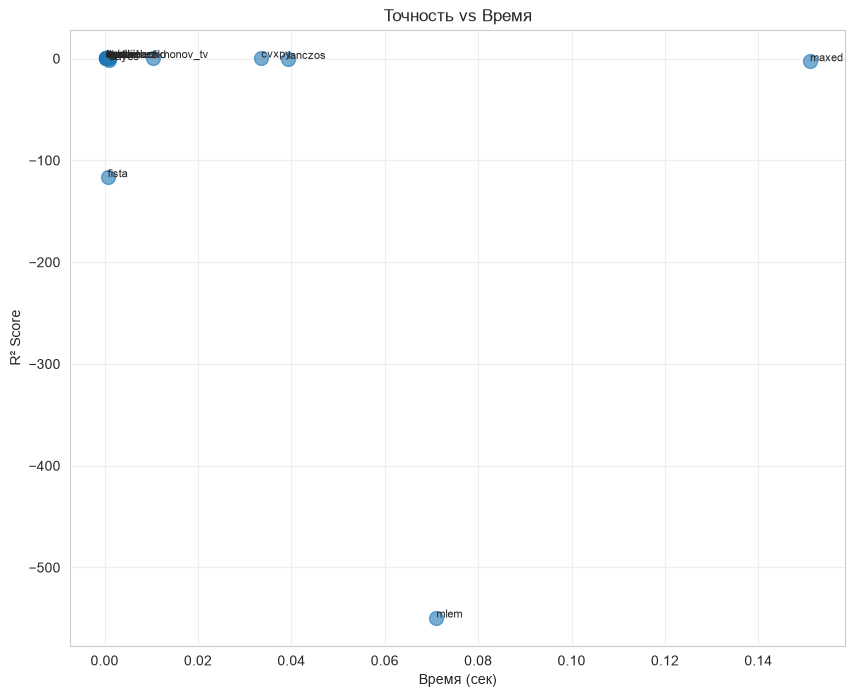

In [11]:
time_avg = result.results.groupby('method')['time_sec'].mean().reset_index()
time_avg.columns = ['method', 'avg_time']
merged = pd.merge(time_avg, summary_table, on='method')

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(merged['avg_time'], merged['r2_score_mean'], s=100, alpha=0.6)
for _, row in merged.iterrows():
    ax.annotate(row['method'], (row['avg_time'], row['r2_score_mean']), fontsize=8)
ax.set_xlabel('Время (сек)')
ax.set_ylabel('R² Score')
ax.set_title('Точность vs Время')
ax.grid(True, alpha=0.3)
plt.savefig('time_vs_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

## Лучший метод: оверлей спектра

Лучший метод по R²: cvxpy (params={'solver': 'ECOS'})


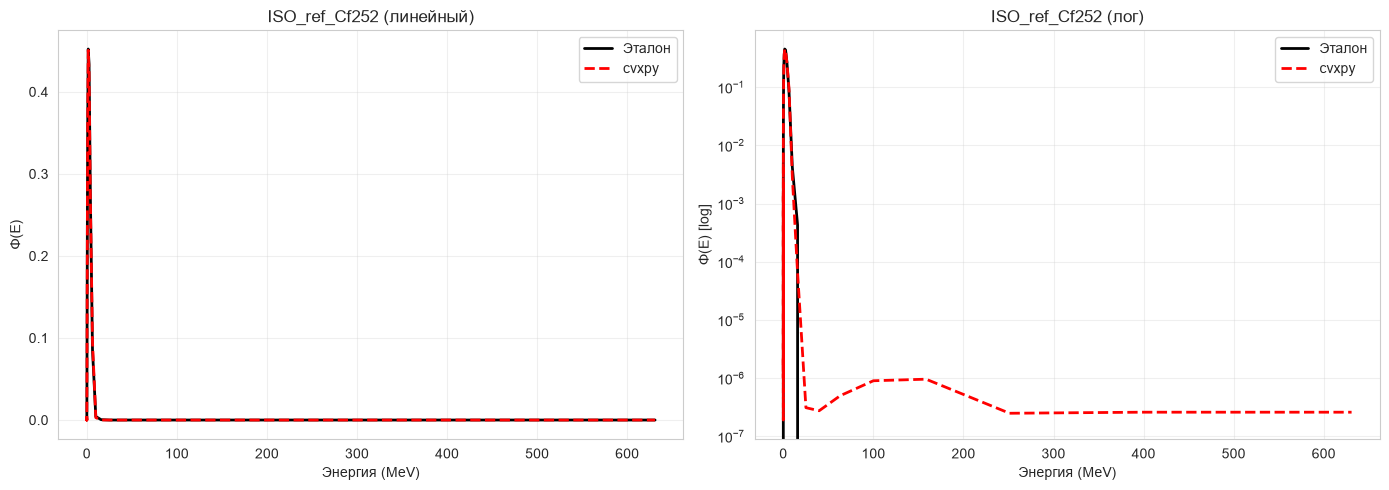

In [12]:
first_spec = TEST_SPECTRA[0]
ref_spec = refs[first_spec]
readings = det.get_effective_readings_for_spectra(ref_spec)

best_method = ranking.iloc[0]['method']
best_cfg = METHODS[best_method]
best_params = best_cfg['params'][0]
best_func = getattr(det, best_cfg['method'])
best_result = best_func(readings, **best_params)
print(f"Лучший метод по R²: {best_method} (params={best_params})")

energy = ref_spec['E_MeV']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(energy, ref_spec['Phi'], 'k-', lw=2, label='Эталон')
axes[0].plot(energy, best_result['spectrum'], 'r--', lw=2, label=best_method)
axes[0].set_xlabel('Энергия (MeV)')
axes[0].set_ylabel('Φ(E)')
axes[0].set_title(f'{first_spec} (линейный)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogy(energy, ref_spec['Phi'], 'k-', lw=2, label='Эталон')
axes[1].semilogy(energy, best_result['spectrum'], 'r--', lw=2, label=best_method)
axes[1].set_xlabel('Энергия (MeV)')
axes[1].set_ylabel('Φ(E) [log]')
axes[1].set_title(f'{first_spec} (лог)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'spectrum_{first_spec}.png', dpi=300, bbox_inches='tight')
plt.show()

## Сравнение нескольких методов на одном спектре

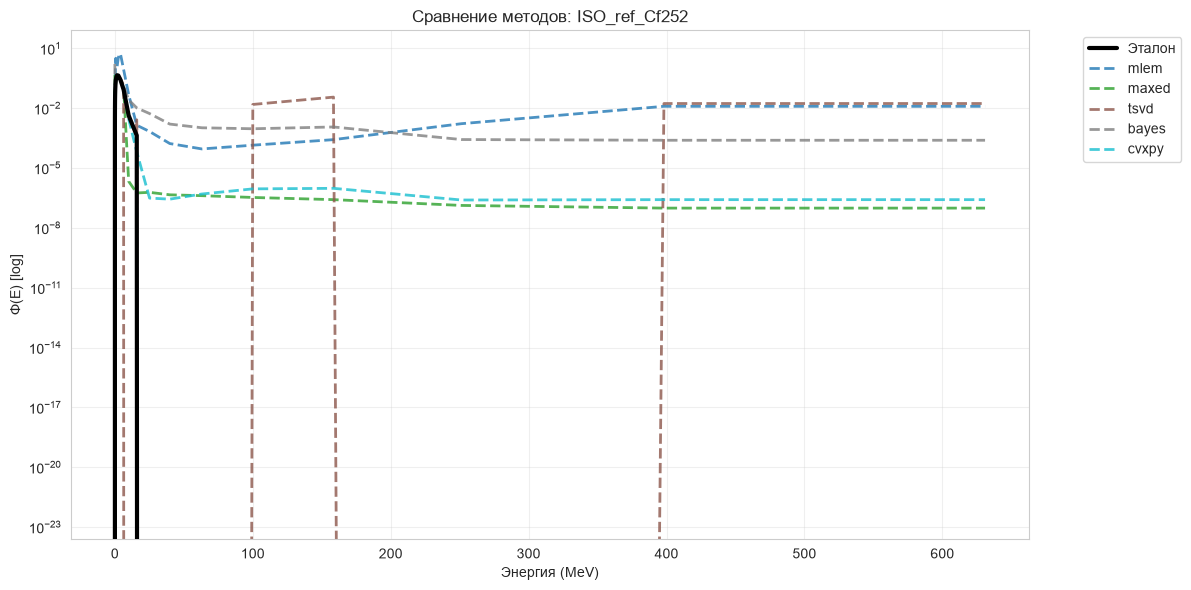

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogy(energy, ref_spec['Phi'], 'k-', lw=3, label='Эталон', zorder=10)
colors = plt.cm.tab10(np.linspace(0, 1, min(5, len(METHODS))))
for i, (mname, mcfg) in enumerate(list(METHODS.items())[:5]):
    try:
        func = getattr(det, mcfg['method'])
        res = func(readings, **mcfg['params'][0])
        ax.semilogy(energy, res['spectrum'], '--', lw=2, color=colors[i], label=mname, alpha=0.8)
    except Exception as e:
        print(f"{mname} skipped: {e}")
ax.set_xlabel('Энергия (MeV)')
ax.set_ylabel('Φ(E) [log]')
ax.set_title(f'Сравнение методов: {first_spec}')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('multi_method.png', dpi=300, bbox_inches='tight')
plt.show()

## Тепловая карта нормализованных метрик

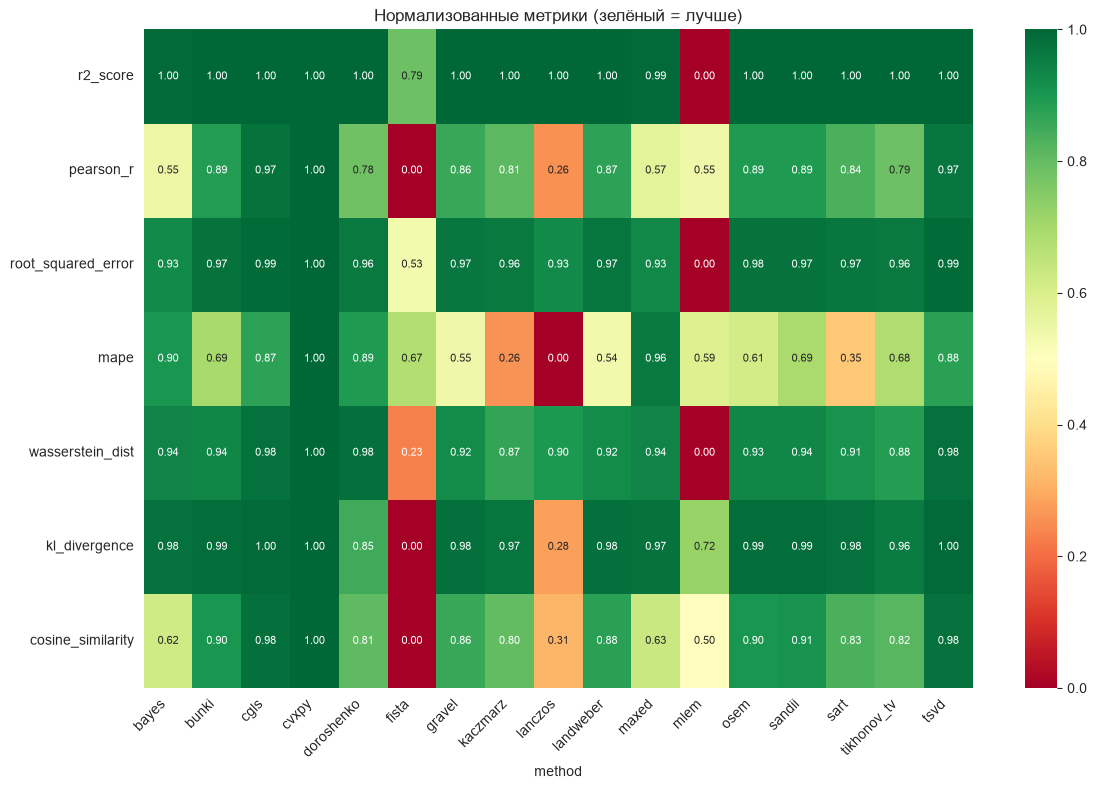

In [14]:
from sklearn.preprocessing import MinMaxScaler

hm_cols = [c for c in summary_table.columns if c.endswith('_mean') and c != 'method']
hm_data = summary_table.copy()
hm_data.index = hm_data['method']
hm_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(hm_data[hm_cols]),
    index=hm_data.index,
    columns=[c.replace('_mean', '') for c in hm_cols],
)
# Для ошибочных метрик инвертируем (меньше = лучше)
for c in hm_norm.columns:
    if any(t in c for t in ('error', 'rmse', 'mape', 'kl_', 'wasserstein')):
        hm_norm[c] = 1.0 - hm_norm[c]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(hm_norm.T, annot=True, fmt='.2f', cmap='RdYlGn', annot_kws={'size': 8}, ax=ax)
ax.set_title('Нормализованные метрики (зелёный = лучше)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Текстовый отчёт

In [15]:
print(result.report)

UNFOLD METHOD COMPARISON REPORT
Spectra: 3 | Methods: 17 | Runs: 111

TOP methods by r2_score (desc):
1. cvxpy                r2_score=0.9866
2. cgls                 r2_score=0.9280
3. tsvd                 r2_score=0.9140
4. osem                 r2_score=0.7296
5. sandii               r2_score=0.7263

Success rate (%):
bayes               : 100.0%
landweber           : 100.0%
tikhonov_tv         : 100.0%
sart                : 100.0%
sandii              : 100.0%
osem                : 100.0%
mlem                : 100.0%
maxed               : 100.0%
lanczos             : 100.0%
bunki               : 100.0%
kaczmarz            : 100.0%
gravel              : 100.0%
fista               : 100.0%
doroshenko          : 100.0%
cvxpy               : 100.0%
cgls                : 100.0%
tsvd                : 100.0%

Time (sec):
cgls                :    0.000
sandii              :    0.000
sart                :    0.000
landweber           :    0.000
osem                :    0.000
tsvd              

## Сохранение результатов

In [ ]:
# ts = datetime.now().strftime('%Y%m%d_%H%M%S')
# result.results.to_csv(f'benchmark_results_{ts}.csv', index=False)
# summary_table.to_csv(f'benchmark_summary_{ts}.csv', index=False)
# print(f"Сохранено: benchmark_results_{ts}.csv, benchmark_summary_{ts}.csv")

Сохранено: benchmark_results_20260823_004211.csv, benchmark_summary_20260823_004211.csv
